<a href="https://colab.research.google.com/github/social410/data_science/blob/master/california_House_Price_prediction_using_Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Importing Libraries

In [103]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

Loading california Housing Dataset

In [104]:
# data = pd.read_csv('/content/housing.csv')
data = pd.read_csv('housing.csv')
# data.head()
data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [105]:
data.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='object')

Data Exploration

In [106]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [107]:
data["ocean_proximity"].unique()

array(['NEAR BAY', '<1H OCEAN', 'INLAND', 'NEAR OCEAN', 'ISLAND'],
      dtype=object)

In [108]:
# Identify missing values
missing_values = data.isnull().sum()

# percentage of missing data in each column
missing_percentage = (missing_values / len(data)) * 100
print("Missing Values in each column:\n", missing_values)
print("\nPercentage of missing data:\n", missing_percentage)

Missing Values in each column:
 longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

Percentage of missing data:
 longitude             0.000000
latitude              0.000000
housing_median_age    0.000000
total_rooms           0.000000
total_bedrooms        1.002907
population            0.000000
households            0.000000
median_income         0.000000
median_house_value    0.000000
ocean_proximity       0.000000
dtype: float64


In [109]:
# remove rows with missing values
data_cleaned = data.dropna()

# verify that missing values have been removed
print("\nNumber of rows in cleaned data:", len(data_cleaned))
print("\nMissing Values in each column after removal:")
print(data_cleaned.isnull().sum())




Number of rows in cleaned data: 20433

Missing Values in each column after removal:
longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64


Data Exploration with Visualization

In [110]:
data.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [111]:
data_cleaned.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000
mean,-119.570689,35.633221,28.633094,2636.504233,537.870553,1424.946949,499.433465,3.871162,206864.413155
std,2.003578,2.136348,12.591805,2185.269567,421.385070,1133.208490,382.299226,1.899291,115435.667099
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1450.000000,296.000000,787.000000,280.000000,2.563700,119500.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.536500,179700.000000
75%,-118.010000,37.720000,37.000000,3143.000000,647.000000,1722.000000,604.000000,4.744000,264700.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


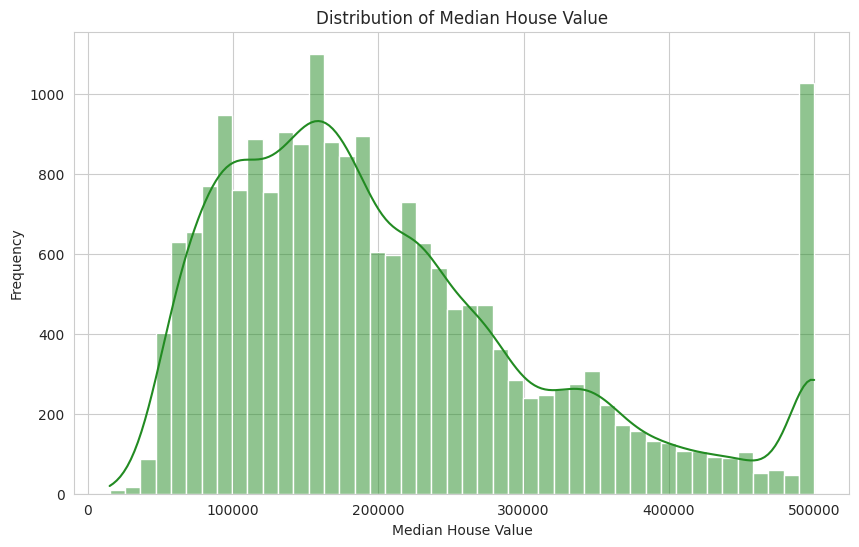

In [112]:
# Visualize dependent variable
sns.set_style('whitegrid')
plt.figure(figsize=(10, 6))
sns.histplot(data_cleaned['median_house_value'], color='forestgreen', kde=True)
plt.title('Distribution of Median House Value')
plt.xlabel('Median House Value')
plt.ylabel('Frequency')
plt.show()

In [113]:
# Removing Outliers using InterQuatile range
Q1 = data_cleaned['median_house_value'].quantile(0.25)
print(Q1)
Q3 = data_cleaned['median_house_value'].quantile(0.75)
print(Q3)
IQR = Q3 - Q1

# defining the boundaries for the outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

119500.0
264700.0


In [114]:
# removing outliers
data_no_outliers_1 = data_cleaned[(data_cleaned['median_house_value'] >= lower_bound) & (data_cleaned['median_house_value'] <= upper_bound)]
# print(data_no_outliers_1)

# checking the shape of the data
print(Q1)
print(Q3)
print("Original data shape:", data_cleaned.shape)
print("New data shape without outliers:", data_no_outliers_1.shape)

119500.0
264700.0
Original data shape: (20433, 10)
New data shape without outliers: (19369, 10)


Using Boxplt to identify Outliers

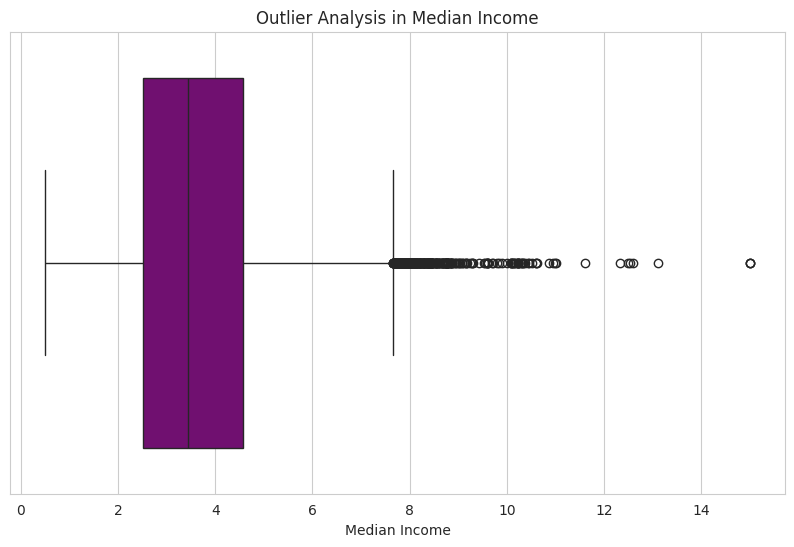

In [115]:
# Boxplot for outlier detection (median income)
plt.figure(figsize=(10, 6))
sns.boxplot(x=data_no_outliers_1['median_income'], color='purple')
plt.title('Outlier Analysis in Median Income')
plt.xlabel('Median Income')
plt.show()




In [116]:
Q1 = data_no_outliers_1['median_income'].quantile(0.25)
print(Q1)
Q3 = data_no_outliers_1['median_income'].quantile(0.75)
print(Q3)
IQR = Q3 - Q1

# defining the boundaries for the outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

data_no_outliers_2 = data_no_outliers_1[(data_no_outliers_1['median_income'] >= lower_bound) & (data_no_outliers_1['median_income'] <= upper_bound)]
#

2.5223
4.5724


In [117]:
# checking the shape
print("Original data shape:", data_no_outliers_1.shape)
print("New data shape without outliers:", data_no_outliers_2.shape)

Original data shape: (19369, 10)
New data shape without outliers: (19026, 10)


In [118]:
data = data_no_outliers_2


Correlation Analysis - Heatmap

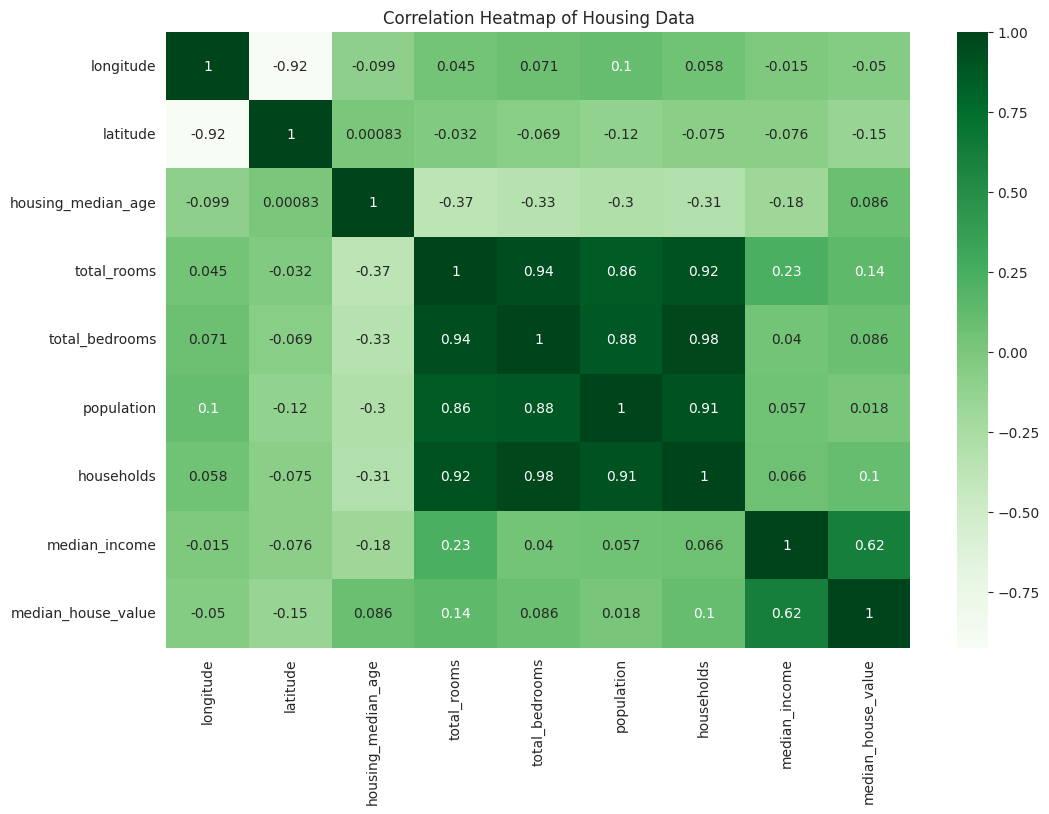

In [119]:
# heatmap
# correlation_matrix = data.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(data.drop('ocean_proximity', axis=1).corr(), annot=True, cmap='Greens')
plt.title('Correlation Heatmap of Housing Data')
plt.show()


In [120]:
# unique value count for categorical data
# categorical_columns = ['ocean_proximity']
for column in ['ocean_proximity']:
    # unique_values = data[column].unique()
    # value_counts = data[column].value_counts()
    print(f"Unique values in {column}:", data[column].unique())
    # print(unique_values)
    # print(f"Value counts in column '{column}':")
    # print(value_counts)
    # print()

Unique values in ocean_proximity: ['NEAR BAY' '<1H OCEAN' 'INLAND' 'NEAR OCEAN' 'ISLAND']


In [121]:
# String data categorization to dummy values
ocean_proximity_dummies = pd.get_dummies(data['ocean_proximity'], prefix='ocean_proximity')
data = pd.concat([data.drop('ocean_proximity', axis=1), ocean_proximity_dummies], axis=1)

In [129]:
ocean_proximity_dummies = ocean_proximity_dummies.astype(int)
ocean_proximity_dummies

,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
2,0,0,0,1,0
3,0,0,0,1,0
4,0,0,0,1,0
5,0,0,0,1,0
6,0,0,0,1,0
...,...,...,...,...,...
20635,0,1,0,0,0
20636,0,1,0,0,0
20637,0,1,0,0,0
20638,0,1,0,0,0


In [130]:
data.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity_<1H OCEAN',
       'ocean_proximity_INLAND', 'ocean_proximity_ISLAND',
       'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN'],
      dtype='object')

In [132]:
data = data.drop('ocean_proximity_ISLAND', axis=1)
data.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity_<1H OCEAN',
       'ocean_proximity_INLAND', 'ocean_proximity_NEAR BAY',
       'ocean_proximity_NEAR OCEAN'],
      dtype='object')

In [133]:
data.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,False,False,True,False
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,False,False,True,False
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,False,False,True,False
5,-122.25,37.85,52.0,919.0,213.0,413.0,193.0,4.0368,269700.0,False,False,True,False
6,-122.25,37.84,52.0,2535.0,489.0,1094.0,514.0,3.6591,299200.0,False,False,True,False


In [142]:
# Splitting the data into training and testing sets
features = ['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'ocean_proximity_<1H OCEAN',
       'ocean_proximity_INLAND', 'ocean_proximity_NEAR BAY',
       'ocean_proximity_NEAR OCEAN']

target = ['median_house_value']

X = data[features]
y = data[target]

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1111)

In [139]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(15220, 13)
(3806, 13)
(15220, 1)
(3806, 1)


In [140]:
# check the size of the splits
print("Training set size:", len(X_train))
print("Testing set size:", len(X_test))

Training set size: 15220
Testing set size: 3806


In [144]:
X_train

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
15578,-116.90,33.03,11.0,3213.0,634.0,1975.0,579.0,3.4750,True,False,False,False
1656,-121.93,37.89,13.0,2085.0,292.0,852.0,264.0,7.3445,False,True,False,False
9190,-118.35,34.32,52.0,102.0,29.0,54.0,32.0,1.9875,True,False,False,False
11839,-120.95,39.93,26.0,2023.0,385.0,922.0,365.0,2.8125,False,True,False,False
12267,-116.91,33.75,13.0,10886.0,2127.0,4266.0,1955.0,2.3169,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
15355,-117.32,33.25,7.0,8206.0,1523.0,4399.0,1423.0,3.6301,True,False,False,False
9608,-120.51,37.29,20.0,4927.0,1042.0,4205.0,1009.0,1.7679,False,True,False,False
12606,-121.49,38.50,32.0,2364.0,439.0,1331.0,449.0,3.3190,False,True,False,False
2907,-119.03,35.37,52.0,1503.0,367.0,554.0,277.0,1.6786,False,True,False,False


In [147]:
# Training by adding constant to the predictors - statsmodels
# Ensure X_train contains only numeric types by converting boolean columns
X_train_numeric = X_train.astype(float) # Convert all columns to float for consistency
X_train_const = sm.add_constant(X_train_numeric)

# fit the old model
model_fitted = sm.OLS(y_train, X_train_const).fit()


# print summary
print(model_fitted.summary())

                            OLS Regression Results                            
Dep. Variable:     median_house_value   R-squared:                       0.594
Model:                            OLS   Adj. R-squared:                  0.593
Method:                 Least Squares   F-statistic:                     1852.
Date:                Fri, 19 Jun 2026   Prob (F-statistic):               0.00
Time:                        16:36:19   Log-Likelihood:            -1.8868e+05
No. Observations:               15220   AIC:                         3.774e+05
Df Residuals:                   15207   BIC:                         3.775e+05
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const               

In [146]:
X_train_const

,const,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
15578,1.0,-116.90,33.03,11.0,3213.0,634.0,1975.0,579.0,3.4750,1.0,0.0,0.0,0.0
1656,1.0,-121.93,37.89,13.0,2085.0,292.0,852.0,264.0,7.3445,0.0,1.0,0.0,0.0
9190,1.0,-118.35,34.32,52.0,102.0,29.0,54.0,32.0,1.9875,1.0,0.0,0.0,0.0
11839,1.0,-120.95,39.93,26.0,2023.0,385.0,922.0,365.0,2.8125,0.0,1.0,0.0,0.0
12267,1.0,-116.91,33.75,13.0,10886.0,2127.0,4266.0,1955.0,2.3169,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
15355,1.0,-117.32,33.25,7.0,8206.0,1523.0,4399.0,1423.0,3.6301,1.0,0.0,0.0,0.0
9608,1.0,-120.51,37.29,20.0,4927.0,1042.0,4205.0,1009.0,1.7679,0.0,1.0,0.0,0.0
12606,1.0,-121.49,38.50,32.0,2364.0,439.0,1331.0,449.0,3.3190,0.0,1.0,0.0,0.0
2907,1.0,-119.03,35.37,52.0,1503.0,367.0,554.0,277.0,1.6786,0.0,1.0,0.0,0.0


In [149]:
# Prediction/Testing
X_test_const = sm.add_constant(X_test)

# Make prediction on test set

y_pred = model_fitted.predict(X_test_const)
y_pred


,0
7322,154464.540269
465,240105.026661
12768,65319.978113
2617,187417.999235
13351,178603.669924
...,...
11691,167578.022635
1454,218723.035673
7360,131405.832854
19118,235655.006992


In [ ]:
# Check OLS Assumptions

# Scatter plot for observed vs predicted values on test data
plt.scatter(y_test, y_pred, color="forestgreen")
plt.xlabel('Observed Values')
plt.ylabel('Predicted Values')
plt.title('Observed vs Predicted Values on Test Data')
plt.show()

In [151]:
# calculate mean of the residual
mean_residuals = np.mean(model_fitted.resid)
print(f"the Mean of the Residuals is {np.round(mean_residuals)}")

the Mean of the Residuals is 0.0


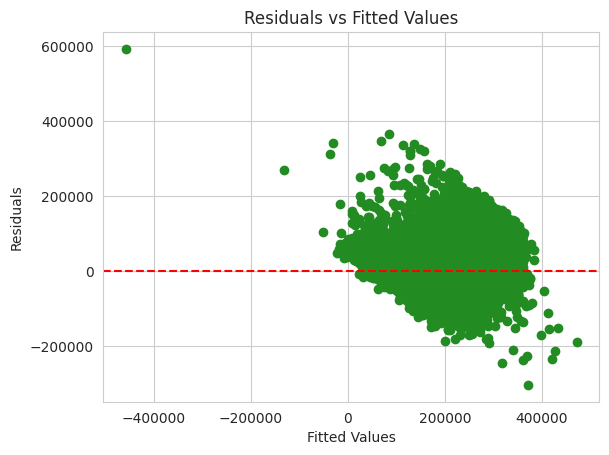

In [153]:
# plotting the residuals with scatterplot
plt.scatter(model_fitted.fittedvalues, model_fitted.resid, color="forestgreen")
plt.axhline(y=mean_residuals, color='red', linestyle='--')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted Values')
plt.show()
